# TCO: retornable vs desechable

Flota multi-planta · 18 meses · 14 plantas · datos MB51 sintéticos

Cuánto cuesta realmente operar con retornables frente a reemplazarlos
con desechables equivalentes, considerando amortización, mantenimiento
y pérdidas por merma.

In [10]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl

DB_PATH = Path("../data/rpi.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

In [11]:
tco = con.execute("""
    SELECT
        tipo_material,
        COUNT(*)                                    AS plantas,
        SUM(ciclos_totales_observados)              AS ciclos_totales,
        MAX(costo_unitario_usd)                     AS costo_unitario_usd,
        MAX(vida_util_ciclos)                       AS vida_util_ciclos,
        MAX(ciclos_payback)                         AS ciclos_payback,
        ROUND(SUM(ahorro_total_vs_desechable_usd), 0) AS ahorro_total_usd,
        ROUND(SUM(perdida_acum_usd), 0)             AS perdida_acum_usd,
        ROUND(SUM(ahorro_neto_usd), 0)              AS ahorro_neto_usd
    FROM mart_tco_comparativo
    GROUP BY tipo_material
    ORDER BY ahorro_neto_usd DESC NULLS LAST
""").pl()

print(tco)

shape: (3, 9)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ tipo_mater ┆ plantas ┆ ciclos_to ┆ costo_uni ┆ … ┆ ciclos_pa ┆ ahorro_to ┆ perdida_a ┆ ahorro_ne │
│ ial        ┆ ---     ┆ tales     ┆ tario_usd ┆   ┆ yback     ┆ tal_usd   ┆ cum_usd   ┆ to_usd    │
│ ---        ┆ i64     ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆         ┆ decimal[3 ┆ decimal[4 ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│            ┆         ┆ 8,0]      ┆ ,1]       ┆   ┆           ┆           ┆           ┆           │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ RACK       ┆ 14      ┆ 923918    ┆ 180.0     ┆ … ┆ 5.0       ┆ 3.71877e7 ┆ 3.63546e6 ┆ 3.355224e │
│            ┆         ┆           ┆           ┆   ┆           ┆           ┆           ┆ 7         │
│ KLT        ┆ 14      ┆ 2085975   ┆ 25.0      ┆ … ┆ 6.0       ┆ 8.62196e6 ┆ 

## 1. Headline

Ahorro neto total de operar con retornables frente a reemplazar
con desechables equivalentes en los 18 meses del dataset.

In [12]:
ahorro_klt  = tco.filter(pl.col("tipo_material") == "KLT")["ahorro_neto_usd"][0]
ahorro_rack = tco.filter(pl.col("tipo_material") == "RACK")["ahorro_neto_usd"][0]
perdida_carton = tco.filter(pl.col("tipo_material") == "CARTON")["perdida_acum_usd"][0]

ahorro_total = ahorro_klt + ahorro_rack

print(f"Ahorro neto KLT:        ${ahorro_klt:>15,.0f}")
print(f"Ahorro neto Rack:       ${ahorro_rack:>15,.0f}")
print(f"─────────────────────────────────────")
print(f"Ahorro neto total:      ${ahorro_total:>15,.0f}")
print()
print(f"Pérdida por merma cartón: ${perdida_carton:>13,.0f}  ← línea base desechable")

Ahorro neto KLT:        $      7,492,410
Ahorro neto Rack:       $     33,552,240
─────────────────────────────────────
Ahorro neto total:      $     41,044,650

Pérdida por merma cartón: $       57,064  ← línea base desechable


## 2. Ahorro neto por tipo de contenedor

KLT y Rack son los únicos tipos con comparativa vs desechable.
Cartón es la línea base — no tiene ahorro porque ES el desechable de referencia,
solo tiene pérdidas por merma.

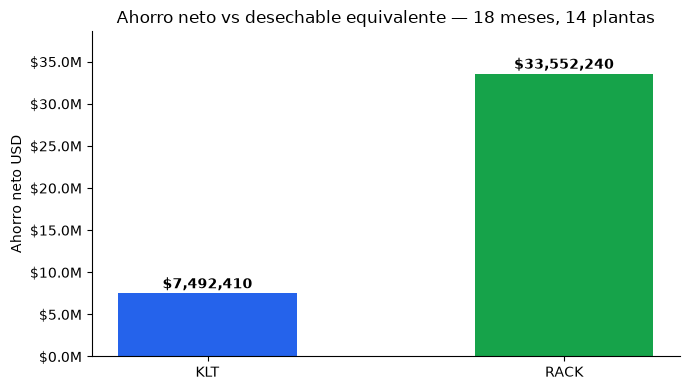

In [13]:
tipos    = ["KLT", "RACK"]
ahorros  = [float(ahorro_klt), float(ahorro_rack)]
colores  = ["#2563eb", "#16a34a"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tipos, ahorros, color=colores, width=0.5)

for bar, val in zip(bars, ahorros):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200_000,
        f"${val:,.0f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_ylabel("Ahorro neto USD")
ax.set_title("Ahorro neto vs desechable equivalente — 18 meses, 14 plantas")
ax.set_ylim(0, max(ahorros) * 1.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/tco_ahorro_neto.png", dpi=150)
plt.show()

## 3. Punto de equilibrio

Cuántos ciclos 601→602 necesita cada contenedor para recuperar
su costo de adquisición frente al desechable equivalente.

In [14]:
payback_data = con.execute("""
    SELECT
        tipo_material,
        MAX(costo_unitario_usd)     AS costo_usd,
        MAX(vida_util_ciclos)       AS vida_util,
        MAX(ciclos_payback)         AS payback
    FROM mart_tco_comparativo
    WHERE tipo_material IN ('KLT', 'RACK')
    GROUP BY tipo_material
    ORDER BY tipo_material
""").pl()

for row in payback_data.iter_rows(named=True):
    margen = row["vida_util"] - row["payback"]
    print(
        f"{row['tipo_material']:6s}  "
        f"costo ${row['costo_usd']:>6.0f}  "
        f"payback {row['payback']:>3.0f} ciclos  "
        f"vida útil {row['vida_util']:>3d} ciclos  "
        f"→ {margen:.0f} ciclos de margen"
    )

KLT     costo $    25  payback   6 ciclos  vida útil 150 ciclos  → 144 ciclos de margen
RACK    costo $   180  payback   5 ciclos  vida útil  80 ciclos  → 75 ciclos de margen


## 4. Costo de la merma

La tasa de no-retorno del 2% erosiona parte del ahorro.
Cuánto se pierde por tipo y qué porcentaje representa del ahorro bruto.

In [15]:
merma_data = con.execute("""
    SELECT
        tipo_material,
        ROUND(SUM(ahorro_total_vs_desechable_usd), 0) AS ahorro_bruto_usd,
        ROUND(SUM(perdida_acum_usd), 0)               AS perdida_merma_usd,
        ROUND(SUM(ahorro_neto_usd), 0)                AS ahorro_neto_usd
    FROM mart_tco_comparativo
    WHERE tipo_material IN ('KLT', 'RACK')
    GROUP BY tipo_material
    ORDER BY tipo_material
""").pl()

print(f"{'Tipo':<8} {'Ahorro bruto':>14} {'Pérdida merma':>14} {'Ahorro neto':>14} {'Merma/Bruto':>12}")
print("─" * 66)
for row in merma_data.iter_rows(named=True):
    pct = row["perdida_merma_usd"] / row["ahorro_bruto_usd"] * 100
    print(
        f"{row['tipo_material']:<8} "
        f"${row['ahorro_bruto_usd']:>13,.0f} "
        f"${row['perdida_merma_usd']:>13,.0f} "
        f"${row['ahorro_neto_usd']:>13,.0f} "
        f"{pct:>11.1f}%"
    )

Tipo       Ahorro bruto  Pérdida merma    Ahorro neto  Merma/Bruto
──────────────────────────────────────────────────────────────────
KLT      $    8,621,960 $    1,129,550 $    7,492,410        13.1%
RACK     $   37,187,700 $    3,635,460 $   33,552,240         9.8%


## 5. Sensibilidad a la tasa de merma

Qué pasa con el ahorro neto si la merma sube de 2% a 4% o baja a 1%.
El costo unitario de KLT es $25 y de Rack es $180 — cada punto de merma
tiene un impacto muy distinto entre tipos.

 Merma        KLT neto       Rack neto      Total neto
────────────────────────────────────────────────────────
   1%  $    8,100,466  $   35,524,648  $   43,625,114
   2%  $    7,578,972  $   33,861,595  $   41,440,568
   3%  $    7,057,479  $   32,198,543  $   39,256,022
   4%  $    6,535,985  $   30,535,490  $   37,071,475
   5%  $    6,014,491  $   28,872,438  $   34,886,929


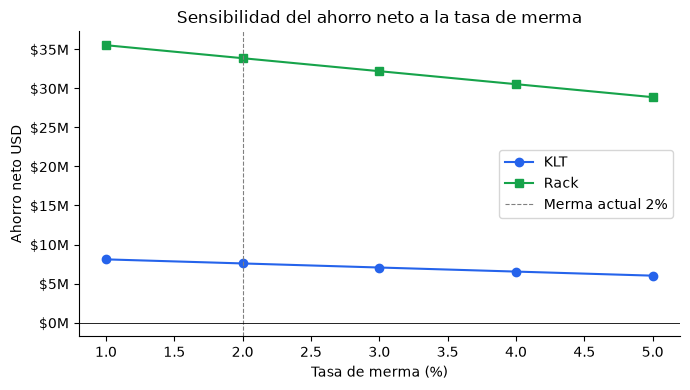

In [16]:
escenarios = [0.01, 0.02, 0.03, 0.04, 0.05]

ciclos_klt  = float(tco.filter(pl.col("tipo_material") == "KLT")["ciclos_totales"][0])
ciclos_rack = float(tco.filter(pl.col("tipo_material") == "RACK")["ciclos_totales"][0])

ahorro_bruto_klt  = float(tco.filter(pl.col("tipo_material") == "KLT")["ahorro_total_usd"][0])
ahorro_bruto_rack = float(tco.filter(pl.col("tipo_material") == "RACK")["ahorro_total_usd"][0])

costo_klt  = 25.0
costo_rack = 180.0

print(f"{'Merma':>6}  {'KLT neto':>14}  {'Rack neto':>14}  {'Total neto':>14}")
print("─" * 56)

netos_klt  = []
netos_rack = []

for tasa in escenarios:
    perdida_klt  = ciclos_klt  * tasa * costo_klt
    perdida_rack = ciclos_rack * tasa * costo_rack
    neto_klt     = ahorro_bruto_klt  - perdida_klt
    neto_rack    = ahorro_bruto_rack - perdida_rack
    netos_klt.append(neto_klt)
    netos_rack.append(neto_rack)
    print(
        f"{tasa:>5.0%}  "
        f"${neto_klt:>13,.0f}  "
        f"${neto_rack:>13,.0f}  "
        f"${neto_klt + neto_rack:>13,.0f}"
    )

# gráfico
fig, ax = plt.subplots(figsize=(7, 4))
pcts = [t * 100 for t in escenarios]
ax.plot(pcts, [v / 1e6 for v in netos_klt],  marker="o", label="KLT",  color="#2563eb")
ax.plot(pcts, [v / 1e6 for v in netos_rack], marker="s", label="Rack", color="#16a34a")
ax.axvline(x=2, color="gray", linestyle="--", linewidth=0.8, label="Merma actual 2%")
ax.axhline(y=0, color="black", linewidth=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.set_xlabel("Tasa de merma (%)")
ax.set_ylabel("Ahorro neto USD")
ax.set_title("Sensibilidad del ahorro neto a la tasa de merma")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/img/tco_sensibilidad.png", dpi=150)
plt.show()

## 6. Resumen ejecutivo

- Operar con KLTs plásticos y racks metálicos genera un ahorro neto de
  **~$41M USD** frente a reemplazarlos con desechables equivalentes
  en 18 meses sobre 14 plantas.

- El rack metálico recupera su inversión en **5 ciclos** y tiene un margen
  de 75 ciclos adicionales de vida útil. El KLT recupera en **6 ciclos**
  con 144 ciclos de margen.

- La merma del 2% erosiona el 13% del ahorro bruto en KLT y el 10% en Rack.
  Cada punto porcentual adicional de merma cuesta ~$2.4M USD anuales sobre esta flota.

- Reducir la tasa de no-retorno de 2% a 1% equivale a recuperar
  ~$1.2M USD adicionales por año sin cambiar nada en la operación.

In [17]:
con.close()